In [18]:
from common_helper_functions import *

In [19]:
path = "../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
go_dna = np.load( path + 'go_dna_dataset.npz')

In [20]:
investigate_dataset(go_dna)

['X', 'y', 'genes']

Array shapes:


X shape: (3697, 12288, 6)
y shape: (3697, 10)
genes shape: (3697,)

First few y values: [[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3

X dimensions: 3
X first sample shape: (12288, 6)
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 1. 0. 0. 0.]
X first sample, first feature vector: [0. 1. 0. 0. 0.]


In [ ]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(go_dna['X'], go_dna['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

In [ ]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 66.42%


In [ ]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, go_dna['genes'], method_name="mrl_pca")
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484532,19.997208,-3.263728,6.096068,2.878531,2.100199,4.996988,3.763492,-2.090862,4.035227,...,-0.954261,-0.194525,-1.458930,-0.514200,-0.931096,-0.382047,-0.315968,-0.258649,-0.917101,-1.090596
FGR,-9.460011,17.357313,-2.683426,-1.475245,5.934589,0.880971,4.911194,-0.139764,5.210984,2.031814,...,1.558398,-0.661263,0.672494,-0.593039,0.207125,0.871022,-0.535321,1.674019,-0.333069,0.528066
CFH,8.703356,23.714708,-4.040073,9.490224,-7.428735,3.553937,-0.899123,-2.731960,-10.455961,5.410274,...,1.742815,-0.931746,1.598274,-0.635915,-0.979871,1.141694,0.462360,-0.962612,2.013518,0.161732
NFYA,15.312574,-8.760341,-8.302403,0.726710,-4.642570,-10.267102,-7.944976,3.541053,4.940825,-1.913313,...,0.145705,-0.304069,-0.413303,2.350329,1.117184,0.946919,0.480336,1.113728,-0.330153,-0.107586
CFTR,20.702272,-18.581985,-19.757858,0.525876,8.217421,4.777900,-9.160739,-4.211007,-1.545545,9.986664,...,-1.874849,-0.578093,1.219241,0.205233,0.047451,-0.183981,0.933764,0.769279,-0.184469,1.054619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407386,5.946119,-1.468880,-10.506932,5.136878,-4.193446,-4.807835,-5.273302,-5.704344,-1.174070,...,0.498130,0.022739,-0.425275,0.010622,0.261727,0.201159,-0.200325,0.147803,0.228955,-0.217654
CPHXL2,-14.601638,-6.739971,-9.937515,-7.373075,-5.923277,-6.634118,-1.230454,-2.815682,-2.358879,-0.869864,...,-0.320858,-0.323570,-0.250110,0.030287,-0.705838,-0.009883,0.131481,0.011298,-0.093527,0.210337
C8orf44-SGK3,-2.840696,14.210366,-2.690852,6.343102,0.053537,2.255665,3.574327,5.975239,-1.967693,2.915431,...,-0.748728,-0.770756,-1.843556,-0.437971,-0.728479,-0.182225,0.279549,-0.580007,0.797507,-1.183887


In [ ]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [ ]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1014,PCA_1015,PCA_1016,PCA_1017,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023
gene_id,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484532,19.997208,-3.263728,6.096068,2.878531,2.100199,4.996988,3.763492,-2.090862,4.035227,...,-0.954261,-0.194525,-1.458930,-0.514200,-0.931096,-0.382047,-0.315968,-0.258649,-0.917101,-1.090596
FGR,-9.460011,17.357313,-2.683426,-1.475245,5.934589,0.880971,4.911194,-0.139764,5.210984,2.031814,...,1.558398,-0.661263,0.672494,-0.593039,0.207125,0.871022,-0.535321,1.674019,-0.333069,0.528066
CFH,8.703356,23.714708,-4.040073,9.490224,-7.428735,3.553937,-0.899123,-2.731960,-10.455961,5.410274,...,1.742815,-0.931746,1.598274,-0.635915,-0.979871,1.141694,0.462360,-0.962612,2.013518,0.161732
NFYA,15.312574,-8.760341,-8.302403,0.726710,-4.642570,-10.267102,-7.944976,3.541053,4.940825,-1.913313,...,0.145705,-0.304069,-0.413303,2.350329,1.117184,0.946919,0.480336,1.113728,-0.330153,-0.107586
CFTR,20.702272,-18.581985,-19.757858,0.525876,8.217421,4.777900,-9.160739,-4.211007,-1.545545,9.986664,...,-1.874849,-0.578093,1.219241,0.205233,0.047451,-0.183981,0.933764,0.769279,-0.184469,1.054619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TAF11L7,-15.407386,5.946119,-1.468880,-10.506932,5.136878,-4.193446,-4.807835,-5.273302,-5.704344,-1.174070,...,0.498130,0.022739,-0.425275,0.010622,0.261727,0.201159,-0.200325,0.147803,0.228955,-0.217654
CPHXL2,-14.601638,-6.739971,-9.937515,-7.373075,-5.923277,-6.634118,-1.230454,-2.815682,-2.358879,-0.869864,...,-0.320858,-0.323570,-0.250110,0.030287,-0.705838,-0.009883,0.131481,0.011298,-0.093527,0.210337
C8orf44-SGK3,-2.840696,14.210366,-2.690852,6.343102,0.053537,2.255665,3.574327,5.975239,-1.967693,2.915431,...,-0.748728,-0.770756,-1.843556,-0.437971,-0.728479,-0.182225,0.279549,-0.580007,0.797507,-1.183887


In [ ]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_1018,PCA_1019,PCA_1020,PCA_1021,PCA_1022,PCA_1023,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
SCYL3,-2.484532,19.997208,-3.263728,6.096068,2.878531,2.100199,4.996988,3.763492,-2.090862,4.035227,...,-0.931096,-0.382047,-0.315968,-0.258649,-0.917101,-1.090596,False,False,False,False
FGR,-9.460011,17.357313,-2.683426,-1.475245,5.934589,0.880971,4.911194,-0.139764,5.210984,2.031814,...,0.207125,0.871022,-0.535321,1.674019,-0.333069,0.528066,False,False,False,False
CFH,8.703356,23.714708,-4.040073,9.490224,-7.428735,3.553937,-0.899123,-2.731960,-10.455961,5.410274,...,-0.979871,1.141694,0.462360,-0.962612,2.013518,0.161732,False,False,False,False
NFYA,15.312574,-8.760341,-8.302403,0.726710,-4.642570,-10.267102,-7.944976,3.541053,4.940825,-1.913313,...,1.117184,0.946919,0.480336,1.113728,-0.330153,-0.107586,False,False,False,False
CFTR,20.702272,-18.581985,-19.757858,0.525876,8.217421,4.777900,-9.160739,-4.211007,-1.545545,9.986664,...,0.047451,-0.183981,0.933764,0.769279,-0.184469,1.054619,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCL3,-15.490881,-0.406351,-2.594800,-9.861933,-1.599851,-4.762448,-4.898940,-4.700238,-5.546411,-3.239632,...,0.167784,0.605286,0.092804,0.136913,0.305674,0.538791,False,False,False,False
SSTR3,4.326702,-5.663806,12.208889,9.123980,1.093335,0.461593,1.553440,-4.534104,-0.840415,-7.032026,...,1.056883,0.933612,2.846386,0.949192,0.887406,1.436676,False,False,False,False
MYO19,5.753113,-14.638560,-17.008024,9.437111,5.493007,7.279556,1.104895,-5.904361,-3.853700,0.653546,...,-1.442330,-0.895247,0.977794,-0.259278,1.970276,2.166542,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [ ]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    2956
True      313
Name: count, dtype: int64

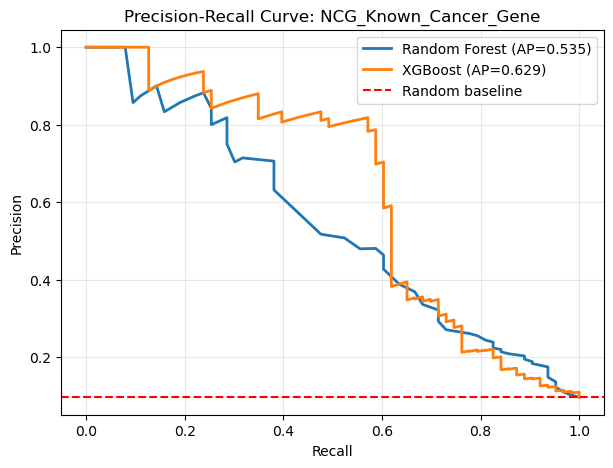

In [ ]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [ ]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    2899
True      370
Name: count, dtype: int64

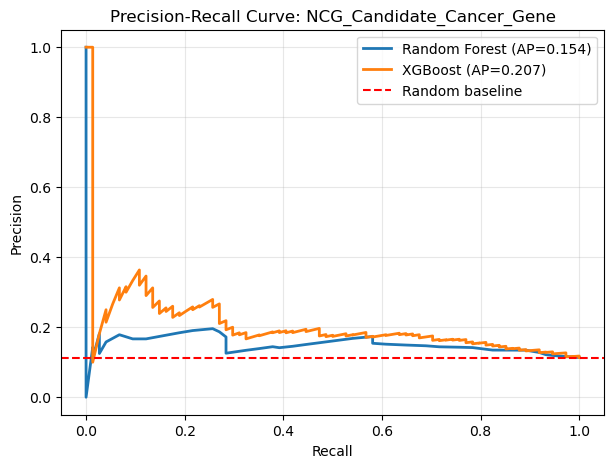

In [ ]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [ ]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    3016
True      253
Name: count, dtype: int64

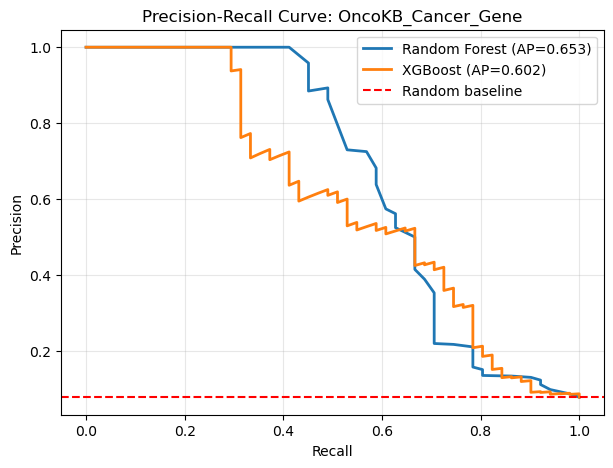

In [ ]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [ ]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    3134
True      135
Name: count, dtype: int64

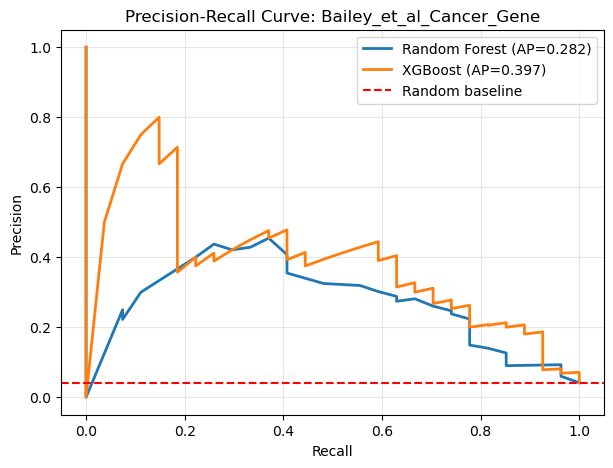

In [ ]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')